In [1]:
import os
import gc
import asyncio
from typing import Type

from connector.monitor import Monitor
from connector.connector import BaseConnector
from connector.binance.binance_perp import BinancePerp
from connector.binance.binance_spot import BinanceSpot

print(f"PID: {os.getpid()}")
connector_type_list: list[Type[BaseConnector]] = [BinancePerp, BinanceSpot]
m = Monitor(connector_type_list=connector_type_list)
gc.disable()
task = asyncio.create_task(m.run())


PID: 2918344


In [7]:
task.cancel()  # отправляем CancelledError в run()
await task 

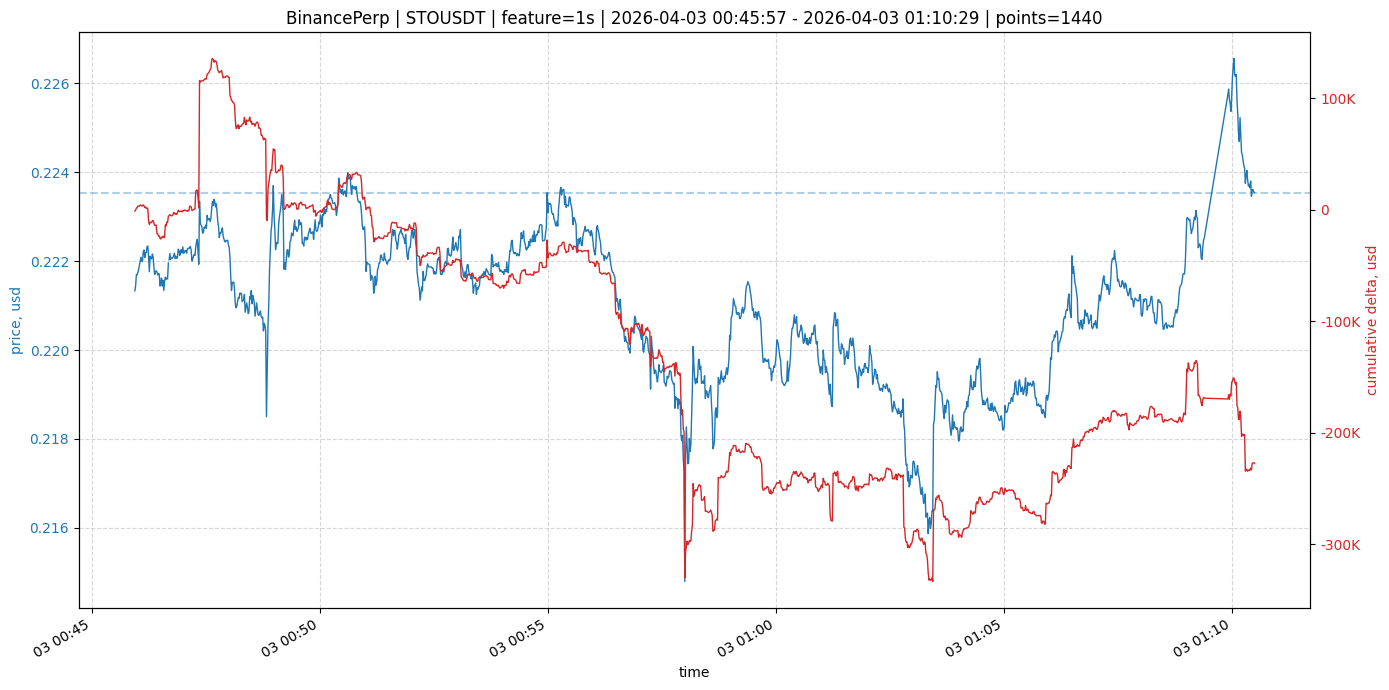

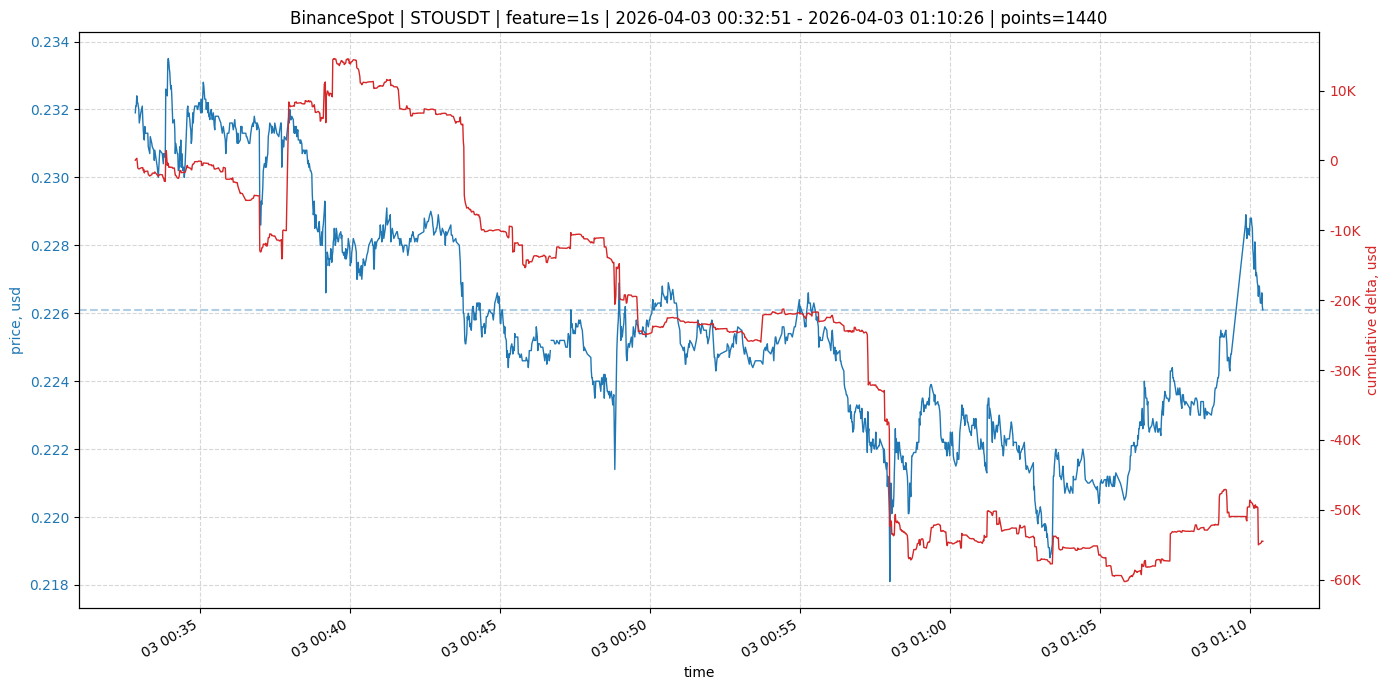

In [5]:
import importlib
import connector.visualization as visual
importlib.reload(visual)

symbol = "STOUSDT"
visual.plot_price_and_cumulative_delta_notional(symbol, m.connectors[BinancePerp], feature="1s")
visual.plot_price_and_cumulative_delta_notional(symbol, m.connectors[BinanceSpot], feature="1s")

In [ ]:
import importlib
import connector.utils_io as utils_io
importlib.reload(utils_io)

await utils_io.save_all_trade_data(m.connectors)

In [ ]:
perp_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinancePerp].instrument_manager.values())
spot_symbols = set(instrument.unified_symbol for instrument in m.connectors[BinanceSpot].instrument_manager.values())
unified_symbols = perp_symbols & spot_symbols
len(perp_symbols), len(spot_symbols), len(unified_symbols)

(542, 439, 371)

In [ ]:
m.connectors[BinancePerp].orderbook_service["BTCUSDT"].message

''

In [ ]:
m.connectors[BinanceSpot].orderbook_service["BTCUSDT"].message

'{"u":91193085088,"s":"BTCUSDT","b":"67026.03000000","B":"2.42203000","a":"67026.04000000","A":"0.24394000"}'

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades

68300.37

In [ ]:
m.connectors[BinanceSpot].trade_service["BTCUSDT"].public_trades_1s

In [4]:
min_delay = 0

In [ ]:
exchange_symbol = "BTCUSDT"
perp_ask_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_ask
perp_bid_price: float = m.connectors[BinancePerp].orderbook_service[exchange_symbol].best_bid
spot_bid_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_bid
spot_ask_price: float = m.connectors[BinanceSpot].orderbook_service[exchange_symbol].best_ask
delay = int(time.time()*1000 - m.connectors[BinanceSpot].orderbook_service[exchange_symbol].transaction_ts_ms)
delay2 = int(time.time()*1000 - m.connectors[BinancePerp].trade_service[exchange_symbol][-1].transaction_ts_ms)
if min_delay>delay:
    min_delay=delay
perp_ask_price, perp_bid_price, spot_bid_price, spot_ask_price, delay-min_delay, delay2-min_delay, min_delay

(0, 0, 0, 0, 76, 65, -1063)

In [ ]:
m.connectors[BinancePerp].orderbook_service.text_data.qsize()

0